In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import gaussian_kde

# 1. Параметры
np.random.seed(123)
theta0 = 2
N = 50
alpha = 0.1

# 2. Генерация выборки
U = np.random.uniform(0, 1, N)
X = 1 - (1 - U)**(1/theta0)

print(f"Первые 5 значений выборки X: {np.round(X[:5], 4)}")
print(f"Основные статистики: mean = {np.mean(X):.4f}, var = {np.var(X):.4f}\n")

Первые 5 значений выборки X: [0.4491 0.1551 0.1207 0.3302 0.4703]
Основные статистики: mean = 0.3223, var = 0.0389



In [4]:
# 3. Оценка параметра θ методом максимального правдоподобия (ОМП)
# ОМП = -N / Σ ln(1-X)
sum_log = np.sum(np.log(1 - X))
theta_hat = -N / sum_log
print(f"Оценка максимального правдоподобия (ОМП): θ_hat = {theta_hat:.4f}")


Оценка максимального правдоподобия (ОМП): θ_hat = 2.1852


In [6]:
# 4. Критерий отношения правдоподобия (Likelihood Ratio Test - LRT)
# Статистика Λ = 2 * (l(θ_hat) - l(θ0)), где l - логарифмическое правдоподобие
lrt_stat = 2 * N * (np.log(theta_hat) - np.log(theta0) - (theta_hat - theta0) / theta_hat)
chi2_crit = stats.chi2.ppf(1 - alpha, df=1)
p_value_lrt = 1 - stats.chi2.cdf(lrt_stat, df=1)

print("Критерий отношения правдоподобия (LRT):")
print(f"  Статистика Λ = {lrt_stat:.4f}")
print(f"  Критическое значение (χ²_{0.9}(1)) = {chi2_crit:.4f}")
print(f"  P-значение = {p_value_lrt:.4f}")

if lrt_stat > chi2_crit:
    print("  >>> Вывод: Отвергаем H0 на уровне значимости 0.1 (статистически значимо).")
else:
    print("  >>> Вывод: Нет оснований отвергнуть H0 на уровне значимости 0.1.")

Критерий отношения правдоподобия (LRT):
  Статистика Λ = 0.3807
  Критическое значение (χ²_0.9(1)) = 2.7055
  P-значение = 0.5372
  >>> Вывод: Нет оснований отвергнуть H0 на уровне значимости 0.1.


In [7]:
# 5. Асимптотический Z-критерий на основе ОМП
# Z = sqrt(N) * (θ_hat/θ0 - 1) асимптотически ~ N(0,1)
z_stat = np.sqrt(N) * (theta_hat / theta0 - 1)
z_crit = stats.norm.ppf(1 - alpha/2)
p_value_z = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))

print("\nАсимптотический Z-критерий:")
print(f"  Z-статистика = {z_stat:.4f}")
print(f"  Критическое значение (z_{{{1-alpha/2:.3f}}}) = ±{z_crit:.4f}")
print(f"  P-значение = {p_value_z:.4f}")

if np.abs(z_stat) > z_crit:
    print("  >>> Вывод: Отвергаем H0 на уровне значимости 0.1.")
else:
    print("  >>> Вывод: Нет оснований отвергнуть H0 на уровне значимости 0.1.")


Асимптотический Z-критерий:
  Z-статистика = 0.6547
  Критическое значение (z_{0.950}) = ±1.6449
  P-значение = 0.5127
  >>> Вывод: Нет оснований отвергнуть H0 на уровне значимости 0.1.


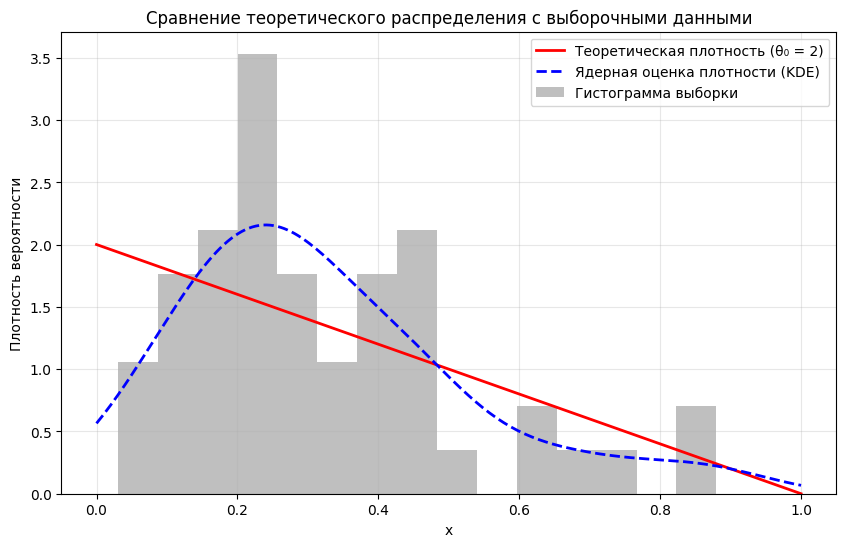

In [8]:
# 6. Визуализация: Ядерная оценка плотности (KDE) vs Теоретическая плотность
from scipy.stats import gaussian_kde

kde = gaussian_kde(X)
x_plot = np.linspace(0, 1, 200)
y_kde = kde(x_plot)
y_theoretical = theta0 * (1 - x_plot)**(theta0 - 1)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_theoretical, 'r-', linewidth=2, label=f'Теоретическая плотность (θ₀ = {theta0})')
plt.plot(x_plot, y_kde, 'b--', linewidth=2, label='Ядерная оценка плотности (KDE)')
plt.hist(X, bins=15, density=True, alpha=0.5, color='gray', label='Гистограмма выборки')
plt.title('Сравнение теоретического распределения с выборочными данными')
plt.xlabel('x')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()